In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [22]:
concrete_data = pd.read_excel('/workspaces/AnaliticaDeDatos/datos/clases/clase_1_analisis_exploratorio_de_datos/Concrete_Data.xls', index_col=False)

In [23]:
columnas = concrete_data.columns
print('Mis variables son :', columnas)

Mis variables son : Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='str')


Vamos a predecir el concrete compressive strenght a partir de cada variable

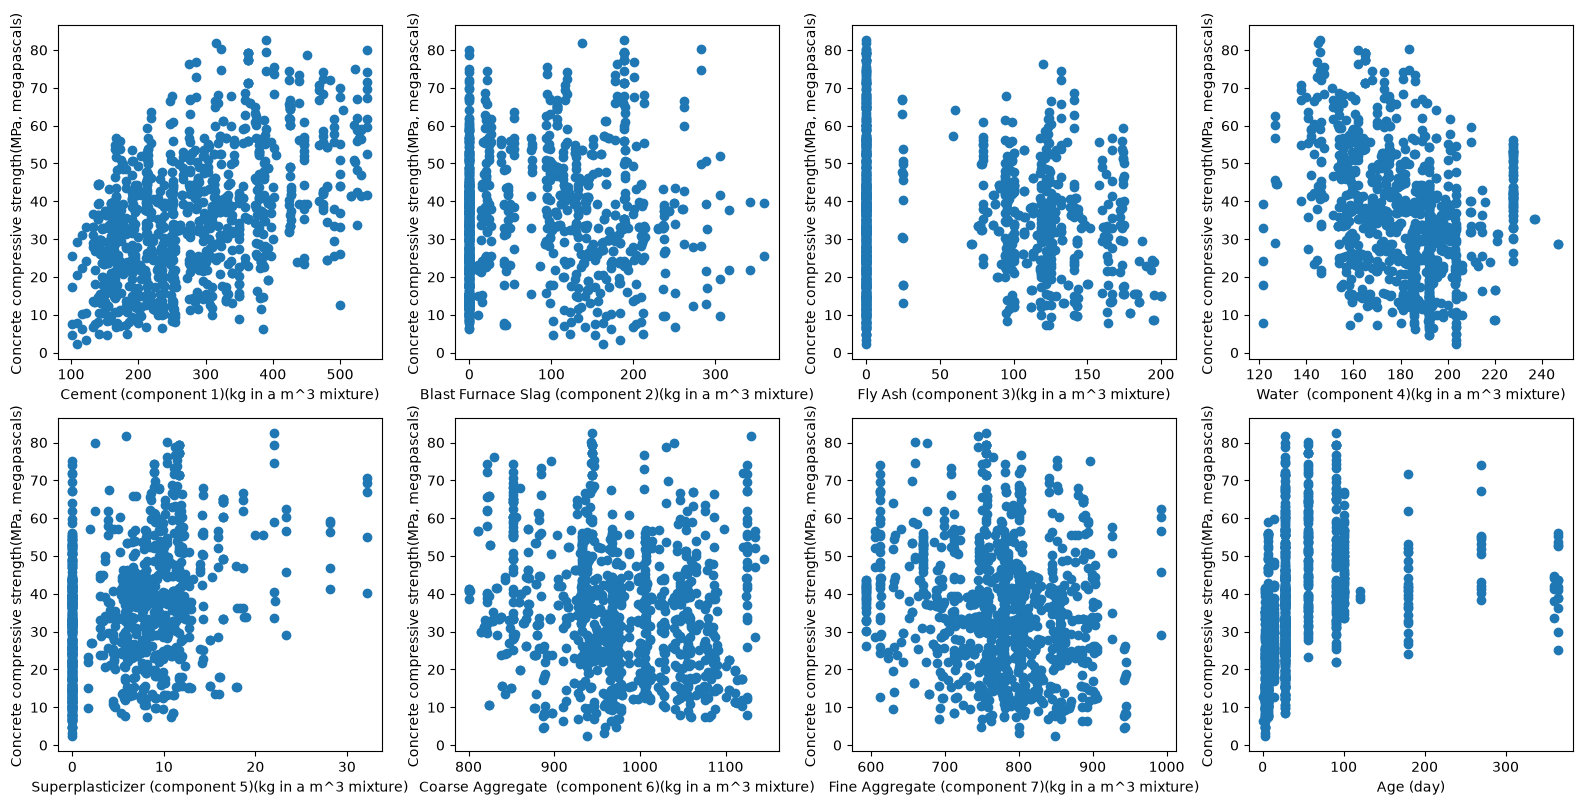

In [24]:
n_predictores = len(columnas) - 1

fig, axes = plt.subplots(2,4,figsize=(16,8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    x = concrete_data[columnas[i]]
    y = concrete_data[columnas[-1]]

    ax.scatter(x,y)

    ax.set_xlabel(columnas[i])
    ax.set_ylabel(columnas[-1])

plt.tight_layout()


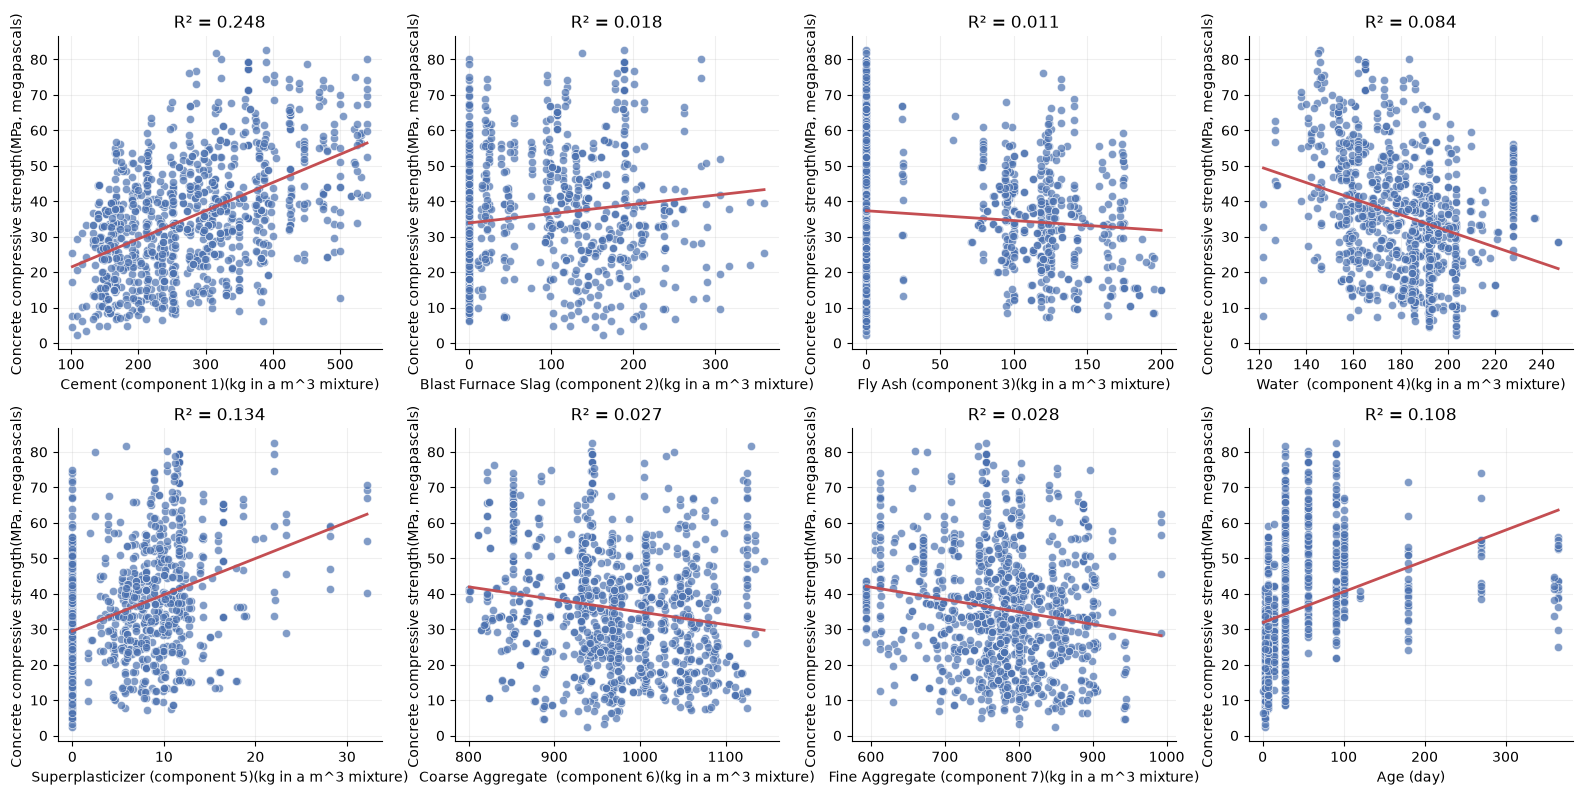

In [25]:
n_predictores = len(columnas) - 1

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= n_predictores:
        ax.axis("off")   # apaga los paneles sobrantes si hay menos de 8 predictores
        continue

    x = concrete_data[columnas[i]]
    y = concrete_data[columnas[-1]]

    pendiente, intercepto = np.polyfit(x, y, 1)
    yhat = intercepto + pendiente * x
    scr = np.sum((y - yhat)**2)
    sct = np.sum((y - y.mean())**2)
    r2 = 1 - scr / sct

    ax.scatter(x, y, color="#4C72B0", alpha=0.7, edgecolor="white", linewidth=0.5, s=35, zorder=2)

    xx = np.linspace(x.min(), x.max(), 100)
    ax.plot(xx, intercepto + pendiente * xx, color="#C44E52", linewidth=2, zorder=3)

    ax.set_xlabel(columnas[i])
    ax.set_ylabel(columnas[-1])
    ax.set_title(f"R² = {r2:.3f}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Vamos a probar con la regresion lineal multiple y vamos a ver el R2 de un modelo que tenga todas las variables como información 

In [28]:
r2

np.float64(0.6154647342687214)

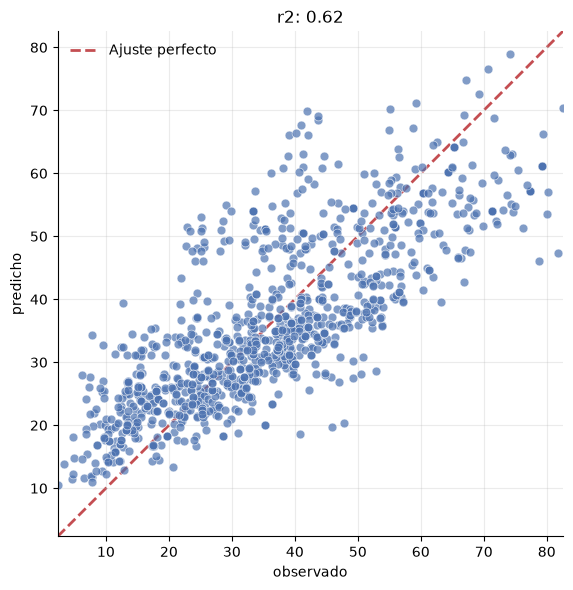

In [32]:
X = concrete_data[columnas[:-1]].values
y = concrete_data[columnas[-1]].values

X_diseno = np.column_stack([np.ones(len(X)), X])  # columna de 1s para el intercepto

beta, _, _, _ = np.linalg.lstsq(X_diseno, y, rcond=None)

yhat = X_diseno @ beta
scr = np.sum((y - yhat)**2)
sct = np.sum((y - y.mean())**2)
r2 = 1 - scr / sct

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, yhat, color="#4C72B0", alpha=0.7, edgecolor="white", linewidth=0.5, s=40, zorder=2)

lims = [min(y.min(), yhat.min()), max(y.max(), yhat.max())]
ax.plot(lims, lims, color="#C44E52", linewidth=2, linestyle="--", zorder=1, label="Ajuste perfecto")

ax.set_xlabel("observado")
ax.set_ylabel("predicho")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title(f'r2: {r2:.2}')
ax.set_aspect("equal", adjustable="box")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.25)
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

 n_predictores                                                                                                                                                                                                                                                                                                                                                        variables       R2         AIC
             1                                                                                                                                                                                                                                                                                                                        Cement (component 1)(kg in a m^3 mixture) 0.247837 8433.108416
             2                                                                                                                                                                                                                

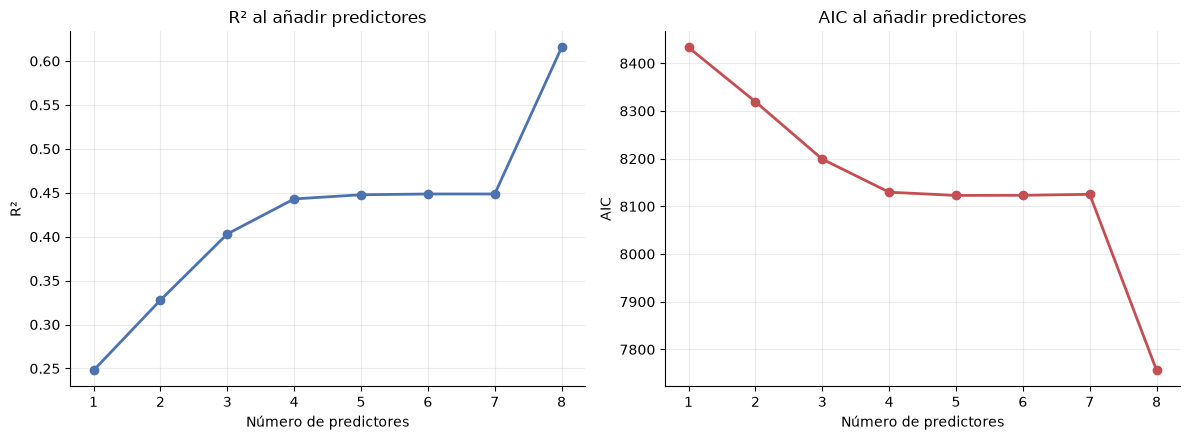

In [33]:
resultados = []

for k in range(1, n_predictores + 1):
    predictores_k = columnas[:k]
    X = concrete_data[predictores_k].values
    y = concrete_data[columnas[-1]].values
    n = len(y)

    X_diseno = np.column_stack([np.ones(n), X])
    beta, _, _, _ = np.linalg.lstsq(X_diseno, y, rcond=None)
    yhat = X_diseno @ beta

    scr = np.sum((y - yhat)**2)
    sct = np.sum((y - y.mean())**2)
    r2 = 1 - scr / sct

    sigma2_mle = scr / n
    loglik = -n/2 * (np.log(2*np.pi) + np.log(sigma2_mle) + 1)
    aic = -2*loglik + 2*(k + 1)  # k predictores + intercepto + varianza

    resultados.append({"n_predictores": k, "variables": ", ".join(predictores_k), "R2": r2, "AIC": aic})

tabla = pd.DataFrame(resultados)
print(tabla.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(tabla["n_predictores"], tabla["R2"], marker="o", color="#4C72B0", linewidth=2)
axes[0].set_xlabel("Número de predictores")
axes[0].set_ylabel("R²")
axes[0].set_title("R² al añadir predictores")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(alpha=0.25)

axes[1].plot(tabla["n_predictores"], tabla["AIC"], marker="o", color="#C44E52", linewidth=2)
axes[1].set_xlabel("Número de predictores")
axes[1].set_ylabel("AIC")
axes[1].set_title("AIC al añadir predictores")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()